<img src="images/banner.png" style="width: 100%;">

# NumPy Basics and Fundamentals

References:

[1] VanderPlas, Jake. *Python data science handbook: Essential tools for working with data. Second Edition* " O'Reilly Media, Inc.", 2023.

[2] McKinney, Wes. *Python for data analysis.* " O'Reilly Media, Inc.", 2022.

[3] Johansson, Robert, Robert Johansson, and Suresh John. *Numerical python.* Vol. 1. New York: Apress, 2019.

[4] NumPy user guide - https://numpy.org/doc/1.26/user/index.html

**NumPy** (short for Numerical Python) is the fundamental package for scientific computing in Python. It is a Python library that provides a multidimensional array object, and various derived objects (such as masked arrays and matrices).

NumPy has an assortment of routines for fast operations on arrays, including mathematical, logical, shape manipulation, sorting, selecting, I/O, discrete Fourier transforms, basic linear algebra, basic statistical operations, random simulations and much more

We will explore in this notebook, the creation, manipulation, aggregation, broadcasting, indexing, and sorting operations of arrays thru NumPy. While some of these operations may seem pedantic, these comprise the building blocks of many other packages such as **pandas** and **sklearn**.


## 1 Why NumPy?

One of the reasons NumPy is so important for numerical computations in Python is because it is designed for efficiency on large arrays of data. There are a number of reasons for this:

- NumPy internally stores data in a contiguous block of memory, independent of other built-in Python objects.
- NumPy operations perform copmlex computations on entire arrays without the need for Python `for` loops, which can be slow for large sequences.

To give you an idea of the performance difference, let's consider a NumPy array of one million integers and compare its performance when it comes to operations wih respect to a Python list:

In [1]:
import numpy as np

In [2]:
my_arr = np.arange(1_000_000)
my_list = list(range(1_000_000))

Let's perform a simple data manipulation by doubling the value in each of the sequence

In [3]:
%timeit my_arr * 2

571 µs ± 24.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [4]:
%timeit [x * 2 for x in my_list]

27.2 ms ± 662 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


NumPy-based algorithms are generally 10 to 100 times faster (or more) than their pure Python counterparts and use significantly less memory.

## 2 The NumPy `ndarray`: A Multidimensional Array Object

One of the key features of NumPy is its N-dimensional array object or `ndarray`, which is a fast, flexible container for large datasets in Python. Arrays enable you to perform mathematical operations on whole blocks of data using similar syntax to the equivalent operations between scalar elements.

To give you a preview on how NumPy objects enable batch computations with similar syntax on built-in Python objects, let's initialize a NumPy array,

In [5]:
data = np.array([[1.5, -0.1, 3],
                 [0, -3, 6.5]])
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

Then we can write mathematical operations with the data, such as scalar multiplication,

In [6]:
data * 10

array([[ 15.,  -1.,  30.],
       [  0., -30.,  65.]])

Or array addition,

In [7]:
data + data

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

### Creating Arrays from Python Lists

Notice that in our initialization of the NumPy array, we used a list to define the array.

In [8]:
my_list = list(range(10))
np.array(my_list)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Remember however, that unlike Python list, NumPy arrays can only contain data of the same type. If the types do not match, NumPy will upcast them according to its type promotion rules; for example, integers will be upcast to floating points.

In [9]:
np.array([3.14, 4, 2, 3])

array([3.14, 4.  , 2.  , 3.  ])

In [10]:
np.array([1, 2.0, '3'])

array(['1', '2.0', '3'], dtype='<U32')

We can use the `dtype` keyword argument to specify the data type.

In [11]:
np.array([1, 2, 3, 4], dtype=np.float32)

array([1., 2., 3., 4.], dtype=float32)

NumPy arrays contain values of a single type, so it is important to have knowledge of those types and their limitations. The standard NumPy data types are listed from the table below.

<img src="images/data-types.png" style="width: 55%;">

More advanced type specification is possible, such as specifying big- or little- endian numberes; for more information refer to the [NumPy documentation](https://numpy.org/doc/stable/reference/arrays.dtypes.html).

### Creating Arrays from Scratch

For larger arrays, it is more efficient to create arrays from scratch using routined built into NumPy. Here are some examples:

In [12]:
# Create a length-10 integer array filled with 0s
np.zeros(10, dtype=int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
# Create a 3x5 floating-point array filled with 1s
np.ones((3, 5), dtype=float)

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [14]:
# Create a 3x5 array filled with 3.14
np.full((3, 5), 3.14)

array([[3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14]])

In [15]:
# Create a 3x3 identity matrix
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [16]:
# Create an unitiialized array of three integers; the values will be
# whatever happens to already exist at the memory location
np.empty(3, dtype=int)

array([4607182418800017408, 4607182418800017408, 4607182418800017408])

In [17]:
# Create an array filled with a linear sequence starting at 0,
# ending at 20, stepping by 2
# (this is similar to the built-in range function)
np.arange(0, 20, 2)

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

See the table below for a short list of standard array creation function. Since NumPy is focused on numerical computing, the data type, if not specified, will in many cases be floating point.

<img src="images/array-creation.png" style="width: 65%;">

Another way to create an array is by specifying the range of the array you wish to create.

In [18]:
# Create an array of five values linearly spaced between 0 and 1
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [19]:
# Create an array of six values logarithmically spaced between 10^-3 to 10^2
np.logspace(-3, 2, 6)

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])

### Creating Arrays using Random Numbers

The `numpy.random` module supplements the built-in Python `random` module with functions for efficiently generating whole arrays of sample values from many kinds of probability distributions.

In [20]:
# Create a 4x4 array of samples from the standard normal dsitribution
np.random.standard_normal(size=(4, 4))

array([[-0.11305074,  0.6049847 ,  0.33248443,  0.90921804],
       [ 0.68500036, -0.40267809, -0.89542954,  0.37466162],
       [ 2.70917586,  0.69887832,  0.97996449, -0.20465289],
       [ 0.29499238,  0.18710316, -1.21064877, -1.63819271]])

These random numbers are not truly random (rather *pseudorandom*) but instead are generated by a configurable random number generator that determines what values are created.

You can explicitly configure this generator by specifying a random seed.

In [21]:
# Create a 2x3 array of samples from the standard normal distribution
rng = np.random.default_rng(seed=1337)
rng.standard_normal((2, 3))

array([[ 0.03826822,  0.47393644, -0.13774592],
       [-1.38933444,  2.52011869, -1.00639095]])

In [22]:
np.random.seed(1337)
np.random.standard_normal(size=(2, 3))

array([[-0.70318731, -0.49028236, -0.32181433],
       [-1.75507872,  0.20666447, -2.01126457]])

See the table below for a partial list of methods available on the random generator objects like `rng` defined here.

<img src="images/np-random.png" style="width: 65%;">

## 3 Array Manipulation

Data manipulation in Python is nearly synonymous with NumPy array manipulation. Here, we present several examples of NumPy to manipulate and acecss data and subarrays, to split, reshape, and join arrays.

First, let's create arrays using random numbers using the cell below:

In [23]:
rng = np.random.default_rng(seed=1337)

x1 = rng.integers(10, size=6) # One-dimensional array
x2 = rng.integers(10, size=(3, 4)) # Two-dimensional array
x3 = rng.integers(10, size=(3, 4, 5 )) # Three-dimensional array

### NumPy Array Attributes

Each array has attributes including `ndim` (the number of dimensions), `shape` (the size of each dimension), `size` (the total size of the array), and `dtype` (the type of each element).

In [24]:
print(f"x3 ndim: {x3.ndim}")
print(f"x3 shape: {x3.shape}")
print(f"x3 size: {x3.size}")
print(f"x3 dtype: {x3.dtype}")

x3 ndim: 3
x3 shape: (3, 4, 5)
x3 size: 60
x3 dtype: int64


### Array Indexing: Accessing Single Elements

In a one-dimensional array, the $i_{\text{th}}$ value (starting from zero) can be accessed by specifying the desired index in square brackets, just as with Python lists:

In [25]:
x1

array([5, 8, 7, 1, 5, 9])

In [26]:
x1[0]

5

In [27]:
x1[3]

1

In [28]:
x1[-1]

9

In [29]:
x1[-2]

5

In a multidimensional array, items can be accessed using comma-separated (row, column) tuple:

In [30]:
x2

array([[3, 9, 2, 8],
       [4, 1, 0, 1],
       [1, 3, 2, 4]])

In [31]:
x2[0, 0]

3

In [32]:
x2[2, 0]

1

In [33]:
x2[2, -1]

4

Values can also be modified using any of the preceding index notation:

In [34]:
x2[0, 0] = 12

In [35]:
x2

array([[12,  9,  2,  8],
       [ 4,  1,  0,  1],
       [ 1,  3,  2,  4]])

Keep in mind that, unlike Python lists, NumPy arrays have a fixed type. This means, that if you attempt to insert a floating-point value into an integer array, the value will be silently truncated.

In [36]:
x1[0] = 3.14159

In [37]:
x1

array([3, 8, 7, 1, 5, 9])

### Array Slicing: Accesssing Subarrays

We can also use the colon `:` character to access subarrays using the *slice* notation. NumPy slicing syntax follows that of the standard Python list:

```
x[start:stop:step]
```

#### One-Dimensional Subarrays

In [38]:
x1

array([3, 8, 7, 1, 5, 9])

In [39]:
x1[:3] # first three elements

array([3, 8, 7])

In [40]:
x1[3:] # elements after index 3

array([1, 5, 9])

In [41]:
x1[1:4] # middle subarray

array([8, 7, 1])

In [42]:
x1[::2] # every second element

array([3, 7, 5])

In [43]:
x1[1::2] # every second element, starting at index 1

array([8, 1, 9])

In [44]:
x[::-1] # all elements reversed

NameError: name 'x' is not defined

In [ ]:
x1[4::-2] # every second element from index 4, reversed

#### Multidimensional Subarrays

In [ ]:
x2

In [ ]:
x2[:2, :3] # first two rows & three columns

In [ ]:
x2[:3, ::2] # three rows, every second column

In [ ]:
x2[::-1, ::-1] # all rows and columns reversed

One common routine is accessing single rows or columns of an array

In [ ]:
x2[:, 0] # first column of x2

In [ ]:
x2[0, :] # first row of x2

In the case of row access, the empty slice can be ommitted

In [ ]:
x2[0]

#### Subarrays as No-Copy Views

Unlike Python list slices, NumPy array slices are returned as views rather than copies of the array data.

In [ ]:
rng = np.random.default_rng(seed=1337)

x1 = rng.integers(10, size=6) # One-dimensional array
x2 = rng.integers(10, size=(3, 4)) # Two-dimensional array
x3 = rng.integers(10, size=(3, 4, 5 )) # Three-dimensional array

x2

In [ ]:
x2_sub = x2[:2, :2]
x2_sub

In [ ]:
x2_sub[0, 0] = 99
x2_sub

In [ ]:
x2

This may surprise some users, but it can be advantageous, especialy when working with large datasets. You can access and process pieces of datasets without the need of copying the underlying data buffer.

#### Creating Copies of Arrays

In the case where we want to explicitly copy the data within the array or subarray, we can use the `copy` method of the array.

In [ ]:
x2_sub_copy = x2[:2, :2].copy()
x2_sub_copy

If we modify this subarray, the original array is untouched:

In [ ]:
x2_sub_copy[0, 0] = 42
x2_sub_copy

In [ ]:
x2

### Reshaping of Arrays

Another useful manipulation is reshaping of arrays. For example, if you want to put the numbers 1 thorugh 9 in a 3x3 grid, you can do the following:

In [ ]:
np.arange(1, 10)

In [ ]:
grid = np.arange(1, 10).reshape(3, 3)
grid

For this to work, the size of the initial array must match the size of the reshaped array. In most cases, the `reshape` method will return a no-copy view of the initial array.

A common operation is converting a one dimensional array into two-dimensional row or column matrix:

In [ ]:
x = np.array([1, 2, 3])
x.reshape((1, 3)) # Row vector via reshape

In [ ]:
x.reshape((3, 1)) # Column vector via reshape

A convenient shorthand for this is using the `np.newaxis` in the slicing syntax:

In [ ]:
x[np.newaxis, :] # Row vector via newaxis

In [ ]:
x[:, np.newaxis] # Column vector via newaxis

### Array Concatenation and Splitting

#### Concatenation of Arrays

Concatenation or joining of two arrays in NumPy is primarily accomplished using the routines `np.concatenate`, `np.vstack`, and `np.hstack`.

In [ ]:
[1, 2, 3] + [7, 8, 9]

In [ ]:
x = np.array([1, 2, 3])
y = np.array([7, 8, 9])
np.concatenate([x, y])

You can also concatnate more than two arrays at once:

In [ ]:
z = np.array([99, 99, 99])
np.concatenate([x, y, z])

It can also be used for two-dimensional arrays:

In [ ]:
grid

In [ ]:
np.concatenate([grid, grid])

You can specify at which axis you will concatenate using the `axis` parameter

In [ ]:
np.concatenate([grid, grid], axis=1)

If your working with arrays of mixed dimensions, it may be clearer to use `np.vstack` (vertical stack), or `np.hstack` (horizontal stack) functions:

In [ ]:
np.vstack([x, grid])

In [ ]:
np.hstack([grid, x[:, np.newaxis]])

For higher-dimensional arrays, `np.dstack` will stack arrays along the third dimension.

#### Splitting of Arrays

The oposite of concatenation is splitting, which is implemented by the functions `np.split`, `np.hsplit`, and `np.vsplit`. For each of these we pass a list of indices giving the split points:

In [ ]:
x = [1, 2, 3, 99, 99, 3, 2, 1]
x1, x2, x3 = np.split(x, [3, 5])
print(x1, x2, x3)

Notice that $N$ split points leads to $N + 1$ subarrays. The related functions `np.hsplit` and `np.vsplit` are similar:

In [ ]:
grid = np.arange(16).reshape(4, 4)
grid

In [ ]:
upper, lower = np.vsplit(grid, [2])
print(upper)
print(lower)

In [ ]:
left, right = np.hsplit(grid, [2])
print(left)
print(right)

Similarly, for higher-dimensional arrays, `np.dsplit` will split arrays along the third axis.

## 4 Computation on NumPy Arrays: Universal Functions

The key to making computations on NumPy fast is to use vectorized operations, generally impleemnted through NumPy's *universal functions (ufuncs)*. This vectorized approach is designed to push the loop into the compiled layer that underlies NumPy, which leads to faster execution as compared to using loops.

Consider that we have an array of values and we'd like to compute the reciprocal of each. A straightforward approach might look like this:

In [ ]:
def compute_reciprocals(values):
    """Compute the reciprocal of each element in values"""
    output = np.empty(len(values))
    for i in range(len(values)):
        output[i] = 1.0 / values[i]

    return output

In [ ]:
# Initialize a big array of data
rng = np.random.default_rng(seed=1337)
big_array = rng.integers(1, 100, size=1_000_000)

In [ ]:
%timeit compute_reciprocals(big_array)

By the use of vectorized opoerations, we complete this operation much much faster

In [ ]:
%timeit 1.0 / big_array

Computations using vectorization are nearly always more efficient than their counterparts implemented through Python loops, especially as the arrays grow in size. As such, any time you see a loop in a NumPy script, consider whether it can be replaced with a vectorized expression.

### Exploring NumPy's Ufuncs

Many ufuncs are simple element-wise transformations, like `numpy.sqrt` or `numpy.exp`:

In [ ]:
arr = np.arange(10)
arr

In [ ]:
np.sqrt(arr)

In [ ]:
np.exp(arr)

These are referred to as *unary* ufuncs. See the following table for examples of unary ufuncs.

<img src="images/unary-ufuncs.png" style="width: 65%;">

Others, such as `numpy.add` or `numpy.maximum` take two arrays (thus, *binary* ufuncs) and return a single array as a result:

In [ ]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)

In [ ]:
x

In [ ]:
y

In [ ]:
np.maximum(x, y)

See the following table for more examples of binary ufuncs.

<img src="images/binary-ufuncs.png" style="width: 65%;">

### Advanced Ufunc Features

Here are some specialized features of ufuncs.

#### Specifying Output

For large calculations, it is sometimes useful to be able to specify the array where the result of the calculation will be stored. For all ufuncs, this can be done using the `out` argument of the function.

In [ ]:
x = np.arange(5)
y = np.empty(5)
np.multiply(x, 10, out=y)

In [ ]:
y

#### Aggregations

For binary ufuncs, aggregations can be computed directly from the object. For example, if we'd like to *reduce* an array with a particular operation, we can use the *reduce* method of any ufunc. A reduce repeatedly applies a given operation to the elements of an array until only a single result remains.

In [ ]:
x = np.arange(1, 6)
np.add.reduce(x)

In [ ]:
np.multiply.reduce(x)

If we'd like to store the intermediate results of the computation, we can use `accumulate`:

In [ ]:
np.add.accumulate(x)

In [ ]:
np.multiply.accumulate(x)

For these particular cases, there are dedicated NumPy functions to compute the results (`np.sum`, `np.prod`, `np.cumsum`, `np.cumprod`).

#### Outer Products

Finally, any ufuncs can compute the output of all pairs of two different inputs using the `outer` method. This allows you to create a multiplication table in one line:

In [ ]:
x = np.arange(1, 6)
np.multiply.outer(x, x)

## 5 Aggregations: `min`, `max`, and Everything in Between

A first step in data exploration is to compute various summary statistics. The most common are mean and standard deviation, which allow you to summarize the "typical" values in a dataset. But other aggregations are useful as well.

We'll try out here the different aggregation functions for working on arrays.

### Summing the Values in an Array

Let's try the summing operation of all values in an array. Python itself can do this using the built-in `sum` function

In [ ]:
rng = np.random.default_rng(seed=1337)
L = rng.random(100)
sum(L)

The syntax is similar to NumPy's `sum` function, and the result is the same in the simplest case:

In [ ]:
np.sum(L)

However, because it execuse the operation in compiled code, NumPy's version of the operation is computed much more quickly.

In [ ]:
big_array = rng.random(1_000_000)

In [ ]:
%timeit sum(big_array)

In [ ]:
%timeit np.sum(big_array)

One thing to be wary of is that `sum` and `np.sum` function are not identical. Specifically, their optional arguments have different meanings.

In [ ]:
sum(L[:, np.newaxis], 1)

In [ ]:
np.sum(L[:, np.newaxis], 1)

`sum(x, 1)` initializes the sum at `1`, meanwhile, `np.sum(x, 1)` sums along the axis `1`.

### Minimum and Maximum

Similarly, we expect that NumPy counterparts of `min` and `max` also operate more quickly

In [ ]:
%timeit min(big_array)

In [ ]:
%timeit np.min(big_array)

For `min`, `max`, `sum`, and several other NumPy aggregates, a shorter syntax is to use the methods of the array itself:

In [ ]:
print(big_array.min(), big_array.max(), big_array.sum())

Whenever possible, make sure that you are using the NumPy version of these aggregates when operating on NumPy arrays.

### Multidimensional Aggregates

We can also take the aggregates along a row or column. For example, we have the 2D array:

In [ ]:
M = rng.integers(0, 10, (3, 4))
M

In [ ]:
M.sum() # Sum across all dimension

In [ ]:
M.min(axis=0) # Minimum within each column

In [ ]:
M.min(axis=1) # Minimum within each row

The way the axis is specified here can be confusing to users coming from other languages. The `axis` keyword specifies the dimension of the array that will be *collapsed*, rather than the dimension that will be returned. So specifying `axis=0` means that the axis `0` will be collapsed.

### Other Aggregation Functions

NumPy providews several other aggregation functions with similar API, and additionally have a `NaN`-safe counterpart that computes the result while ignoring missing values. See the table below for a list of useful aggregation functions in NumPy:

<img src="images/agg.png" style="width: 50%;">

## 6 Computation on Arrays: Broadcasting

*Broadcasting* is a set of rules by which NumPy lets you operate between arrays of different sizes and shapes. It can be a powerful feature, but it can cause confusion, even for experienced users.

The simplest example of broadcasting occurs when combining a scalar value with an array:

In [ ]:
a = np.array([0, 1, 2])
a + 5

Here, we can think of broadcasting as an operation that stretches or duplicates the value `5` into the array `[5, 5, 5]` and adds the result.

We can extend this idea to arrays of higher dimension. Observe the result when we add a one-dimensional array to a two-dimensional array:

In [ ]:
M = np.ones((3, 3))
M

In [ ]:
M + a

Here, the one-dimensional array `a` is stretched, or broadcasted, across the second dimension in order to match the shape of `M`.

While these examples are easy to understand, there are complicated cases that can involve broadcasting of both arrays:

In [ ]:
a = np.arange(3)
b = np.arange(3)[:, np.newaxis]
print(a)
print(b)

In [ ]:
a + b

Similar as the previous two cases, we stretched or broadcasted one value to match the shape of the other. here, we stretched both `a` and `b` to match a common shape, and the result is a two-dimensional array. The geometry of these examples is visualized by the figure below.

<img src="images/broadcast-viz.png" style="width: 50%;">

### Rules of Broadcasting

The broadcasting in NumPy follows a strict set of rules to determine the interaction between two arrays. Here are the rules enumerated:

*Rule 1*

> If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is *padded* with ones on its leading (left) side.

*Rule 2*

> If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape

*Rule 3*

> If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

#### Broadcasting Example 1

Suppose we add a two-dimensional array to a one-dimensional array

In [ ]:
M = np.ones((2, 3))
a = np.arange(3)
print(M)
print(a)

In [ ]:
M.shape

In [ ]:
a.shape

By rule 1, the array `a` has fewer dimensions, so we pad it on the left with ones.

- `M.shape` remains (2, 3)
- `a.shape` becomes (1, 3)

By rule 2, we see that the first dimension disagrees, as such, we stretch the dimension to match:

- `M.shape` remains (2, 3)
- `a.shape` becomes (2, 3)

The shapes now match, and we see that the final shape will be `(2, 3)`:

In [ ]:
M + a

In [ ]:
(M + a).shape

#### Broadcasting Example 2

Now let's look at an example where both arrays needed to be broadcasted.

In [ ]:
a = np.arange(3).reshape((3, 1))
b = np.arange(3)
print(a)
print(b)

In [ ]:
a.shape

In [ ]:
b.shape

Rule 1 says that we pad the shape of `b` with ones:

- `a.shape` remains (3, 1)
- `b.shape` becomes (1, 3)

Rule 2 tells us to upgrade each of the 1s to match the corresponding size of the other array:

- `a.shape` remains (3, 3)
- `b.shape` becomes (3, 3)

Because the results match, the shapes are compatible. We get,

In [ ]:
a + b

In [ ]:
(a + b).shape

#### Broadcasting Example 3

Now let's look at an example in which the arrays are incompatible.

In [ ]:
M = np.ones((3, 2))
a = np.arange(3)
print(M)
print(a)

In [ ]:
M.shape

In [ ]:
a.shape

Rule 1 tells us to pad the shape of `a`

- `M.shape` remains (3, 2)
- `a.shape` becomes (1, 3)

Rule 2, the first dimension of `a` is then stretched to match `M`

- `M.shape` remains (3, 2)
- `a.shape` becomes (3, 3)

Now we hit rule 3, the final shapes do not match, so these arrays are incompatible, as we can observe in the operation:

In [ ]:
M + a

Notice that we can make `M` and `a` compatible by reshaping the array `a` as `(3, 1)`. This is not automatically done by NumPy so as to prevent any ambiguity. The broadcasting rules are clear and we must do such reshaping operations manually if we wish our code to behave as such.

In [ ]:
M + a[:, np.newaxis]

While we've been focusing on the `+` operator here, these broadcasting rules apply to any binary ufunc.

### Broadcasting in Practice

What are the cases in which broadcasting is useful? We demonstrate two examples - mean centering and generating a two-dimensional function.

#### Centering an Array

One commonly seen example in data science where broadcasting is useful when we subtract the row-wise mean from an array of data. Imagine we have an array of 10 observations, each of which consists of 3 values.

In [ ]:
X = rng.random((10, 3))
X

We can compute the mean of each column using the `mean` aggregate across the first dimension.

In [ ]:
X_mean = X.mean(0)
X_mean

And now wecan center the array `X` by subtracting the mean (this is a broadcasting operation):

In [ ]:
X_centered = X - X_mean
X_centered

Verify that the centered array has a zero mean.

In [ ]:
X_centered.mean(axis=0)

#### Plotting a Two-Dimensional Function

Another case in which broadcasting is handy is when displaying images based on two-dimensional functions. Consider the Rosenbrock function:

$$
f(x, y) = (a - x)^2 + b(y - x^2)^2
$$

with $a = 1$ and $b = 100$.

In [45]:
# x and y have 100 points linearly spaced for each range
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)[:, np.newaxis]

print(x.shape)
print(y.shape)

(100,)
(100, 1)


We compute $z = f(x, y)$ as a broadcasted operation

$z =  (1-x)^2 + 100(y-x^2)^2$

In [46]:
z = (1 - x)**2 + 100*(y - x**2)**2
print(z.shape)

(100, 100)


Then using `matplotlib` to plot the function:

In [47]:
import matplotlib.pyplot as plt

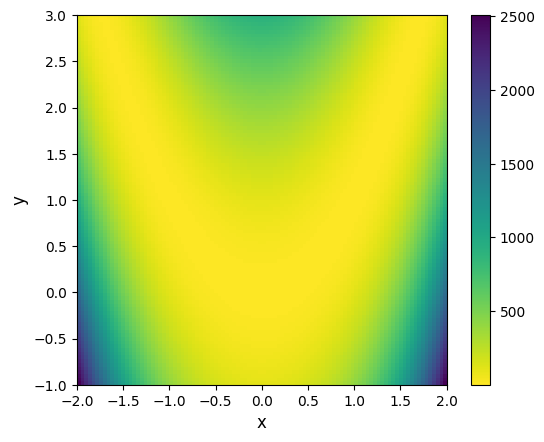

In [48]:
fig, ax = plt.subplots()

im = ax.imshow(z, origin='lower', extent=[-2, 2, -1, 3], cmap='viridis_r')
fig.colorbar(im)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12);

## 7 Boolean and Fancy Indexing

A technique that we can use to specify and select data of interests is through *boolean* and *fancy* indexing.

*Boolean indexing* refers to the use of boolean masks to select subsets of data. Meanwhile, *fancy indexing* refers to passing an array of indices to access multiple array elements at once. We will demonstrate these features in this section.

### Boolean Indexing

Let's consider an example where we have some data in an array and an array of names with duplicates:

In [ ]:
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2],
                 [-12, 4], [3, 4]])
names

In [ ]:
data

Suppose each name corresponds to a row in the data array and we wanted to select all the rows with the corresponding name "Bob". like arithmetic operations, we can use comparisons (such as `==`) as vectorized operations. Thus, comparing names with the string "Bob" yields a Boolean array:

In [ ]:
names == "Bob"

This Boolean array can be passed when indexing the array:

In [ ]:
data[names == "Bob"]

The Boolean array must be of the same length as the array it's indexing. You can even mix and match Boolean array with slices or integers.

In [ ]:
data[names == "Bob", 1:]

In [ ]:
data[names == "Bob", 1]

To select everything but `"Bob"` you can either use `!=` or negate the condition using the `~` operator.

In [ ]:
names != "Bob"

In [ ]:
~(names == "Bob")

In [ ]:
data[~(names == "Bob")]

The `~` operator can be useful when you want to invert a Boolean array referenced by a variable:

In [ ]:
cond = names == "Bob"

In [ ]:
data[~cond]

To select two of the three names to combine multiple Boolean conditions, use Boolean arithmetic operators like `&` (and), `|` (or), and `^` (xor):

In [ ]:
mask = (names == "Bob") | (names == "Will")
mask

In [ ]:
data[mask]

Selecting data from an array by Boolean indexing and assigning the result to a new variable *always* creates a copy of the data, even if the returned array is unchanged.

In [ ]:
masked_data = data[mask]
masked_data

In [ ]:
masked_data[0, 0] = 99
masked_data

In [ ]:
data

Setting values with Boolean array works by substituting the value or values on the righthand size into the locations where the Boolean array's values are `True`. Example, to set all the negative values of the data to `0`, we need to do:

In [ ]:
data[data < 0] = 0
data

You can also set whole rows or columns using a one-dimensional Boolean array:

In [ ]:
print(names)
print(data)

In [ ]:
data[names != "Bob"]

In [ ]:
data[names != "Bob"] = 7
data

#### Using the Keywords `and` / `or` Versus the Operators `&`/ `|`

One common point of confusion is the difference between the keywords `and` and `or` on the one hand, and the operators `&` and `|` on the other. When would you use one versus the other?

The difference is this: `and` and `or` operate on the object as a whole, while `&` and `|` operate on the elements within the object.

Consider the following cases

In [ ]:
(names == "Bob") | (names == "Will")

In [ ]:
(names == "Bob") or (names == "Will")

In [ ]:
np.any(names == "Bob") or np.any(names == "Will")

In [ ]:
np.any(names == "Bob") | np.any(names == "Will")

Remember: `and` and `or` perform a single Boolean evaluation on an entire object, while `&` and `|` perform multiple Boolean evaluation on the content of an object.

### Fancy Indexing

Fancy indexing is a term adopted by NumPy to describe indexing using integer arrays. Suppose we had an 8 x 4 array:

In [ ]:
arr = np.zeros((8, 4))
for i in range(8):
    arr[i] = i
arr

To select a subset of rows in particular order, you can simply pass a list or `ndarray` of integers specifying the desired order:

In [ ]:
arr[[4, 3, 0, 6]]

Using negative indices selects rows from the end:

In [ ]:
arr[[-3, -5, -7]]

When using arrays of indices, the shape of the result reflects the shape of the *index arrays* rather than the shape of the *array being indexed*:

In [ ]:
rng = np.random.default_rng(seed=1337)
x = rng.integers(100, size=10)
x

In [ ]:
ind = np.array([[3, 7],
                [4, 5]])
x[ind]

Fancy indexing also works in multiple dimensions. Consider the following array:

In [ ]:
arr = np.arange(12).reshape((3, 4))
arr

In [ ]:
row = np.array([0, 1, 2, 2])
col = np.array([2, 1, 3, 2])
arr[row, col]

Here, the elements `(0, 2)`, `(1, 1)`, `(2, 3)`, and `(2, 2)` were selected. The result of fancy indexing with as many integer arrays as there are axes is always one-dimensional.

In [ ]:
arr[row[:, np.newaxis], col]

In [ ]:
row[:, np.newaxis]

In [ ]:
col

### Example: Selecting Random Points

One common use of fancy indexing is the selection of subsets of rows from a matrix. For example, we might have an $N \times D$ matrix representing $N$ points in $D$ dimensions, such as the following points drawn from a two-dimensional normal distribution:

In [ ]:
mean = [0, 0]
cov = [[1, 2],
       [2, 5]]
X = rng.multivariate_normal(mean, cov, 100)
X.shape

Let's visualize the points in a scatter plot.

In [ ]:
fig, ax = plt.subplots()

ax.grid()
ax.scatter(X[:, 0], X[:, 1], zorder=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("x")
ax.set_ylabel("y");

Let's use fancy indexing to select 20 random points.

In [ ]:
np.random.seed(1337)
indices = np.random.choice(X.shape[0], 20, replace=False)
indices

In [ ]:
selection = X[indices]
selection.shape

Now let's see which points were selected, let's overplot large circles at locations of the selected points.

In [ ]:
ax.scatter(selection[:, 0], selection[:, 1], facecolor='none',
           edgecolor='tab:orange', s=200, lw=3.0, zorder=11)
fig

### Modifying Values with Fancy Indexing

We can also use to modify parts of an array using fancy indexing.

In [ ]:
x = np.arange(10)
i = np.array([2, 1, 8, 4])
x[i] = 99
x

We can also use any assignment-type operator for this. For example,

In [ ]:
x[i] -= 10
x

Notice that repeated indices can cause some potentially unexpected results. Consider the following:

In [ ]:
x = np.zeros(10)
x[[0, 0]] = [4, 6]
x

This operation assigns `x[0] = 4`, followed by `x[0] = 6`. The result of course is that `x[0]` contains the value `6`.

Consider also this operation:

In [ ]:
i = [2, 3, 3, 4, 4, 4]
x[i] += 1
x

We might expect `x[3]` to conatin value `2` and `x[4]` to contain the value `3`. Why is this not the case? This is because when the expression is evaluated, it is not the augmentation that happens multiple times, but the assignment, which leads to rather nonintuitive results.

If you want the other behavior where in the operation is repeated, you can use the `at` method of `ufuncs`

In [ ]:
x = np.zeros(10)
np.add.at(x, i, 1)
x

## 8 Sorting Arrays

Now let's cover algorithms that is related to sorting values in NumPy arrays.

### Fast Sorting in NumPy: `np.sort` and `np.argsort`

The `np.sort` function is analogous to Python's built-in sorted function and will efficiently return a sorted copy of an array:

In [ ]:
x = np.array([2, 1, 4, 3, 5])
np.sort(x)

Similarly, you can use the `sort` method to sort an array in-place.

In [ ]:
x

In [ ]:
x.sort()
x

A related function is `argsort`, which returns instead the `indices` of the sorted elements:

In [ ]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)
i

In [ ]:
x[i]

### Sorting Along Rows or Columns

You can sort along a specific `rows` or columns by specifying the `axis` argument.

In [ ]:
rng = np.random.default_rng(seed=1337)
X = rng.integers(0, 10, (4, 6))
X

In [ ]:
np.sort(X, axis=0) # Sort each column of X

In [ ]:
np.sort(X, axis=1) # Sort each row of X

Keep in mind that this treats each row or column as an independent array, and any relationships between the row or column values will be lost!

### Partial Sorts: Partitioning

Sometimes we're not interested in sorting the entire array but simply want to find the $k$ smallest values in the array. We can do this by using the `np.partition` function.

`np.partition` takes an array and a number `k`; the result is a new array with the smallest $k$ values to the left of the partition and the remaining values to the right:

In [ ]:
x = np.array([7, 2, 3, 1, 6, 5, 4])
np.partition(x, 3)

The result is an array where the first two slots in each row contain the smallest values from that row, with the remaining values filling the remaining slots.

Finally, there is also a corresponding `np.argsortpartition` that computes the indices of the partition.

### Example: k-Nearest Neighbors

Suppose we might want to find the nearest neighbors of each point in a set. We can do this by using the `argsort` function along multiple axes.

Let's start by creating a random set of 10 points on a two-dimensional plane.

In [ ]:
X = rng.random((10, 2))

In [ ]:
fig, ax = plt.subplots()

ax.grid()
ax.scatter(X[:, 0], X[:, 1], s=100, zorder=100)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("x")
ax.set_ylabel("y");

Next, let's compute the distance between each pair of points.

In [ ]:
dist_sq = np.sum((X[:, np.newaxis] - X[np.newaxis, :])**2, axis=-1)
dist_sq.shape

As a sanity check, the diagonal elements of this matrix shoudl be zero.

In [ ]:
dist_sq.diagonal()

We can now use `np.argsort` to sort along each row.

In [ ]:
nearest = np.argsort(dist_sq, axis=1)
nearest

By using a full sort here, we've actually done more work than we needed. Let's say we are only interested with the nearest $k$ neighbors. All we need to do is partition each row so that the smallest $k + 1$ squared distances come first. With larger distances filling the remaining positions of the array.

In [ ]:
k = 2
nearest_partition = np.argpartition(dist_sq, k + 1, axis=1)

Let's visualize the result

In [ ]:
for i in range(X.shape[0]):
    for j in nearest_partition[i, 1:k + 1]:
        ax.plot(*zip(X[j], X[i]), color='black')
        
fig.suptitle("Visualization of the nearest neighbor of each point")
fig

## 9 Supplemental Exercises

For more hands-on exercises with using Numpy, go to the following resources:

1. https://codesolid.com/numpy-practice-questions-to-make-you-an-expert/
2. https://www.practiceprobs.com/problemsets/python-numpy/
3. https://github.com/rougier/numpy-100

In [ ]:
import numpy as np

a = np.array([1,2,0,0,4,0])

In [ ]:
# Find indices where a is non-zero

In [ ]:
np.where(a!=0)

<img src="images/banner-down.png" style="width: 100%;">